### NAME: SAMUEL ATEKHA OSAGHAE

#### STUDENT ID:2120094

###### JANUARY 2021 ANALYSIS OF COVID 19 WORLD DATA

In [33]:
import os, re, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import IFrame
from IPython.display import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [34]:
root = 'Covid'
recent_date = "01-31-2021"
previous_date = "01-02-2021"
duplicate_columns = {"Lat": "Latitude", 
                     "Long_": "Longitude",
                     "Incidence_Rate": "Incident_Rate",
                     "Case-Fatality_Ratio": "Case_Fatality_Ratio",
                     "Province/State": "Province_State",
                     "Country/Region": "Country_Region",
                     "Last Update": "Last_Update"}

recent_df = pd.read_csv(os.path.join(root, (recent_date + ".csv")))
previous_df = pd.read_csv(os.path.join(root, (previous_date + ".csv")))
for key, value in duplicate_columns.items(): 
    if key in recent_df.columns:
        recent_df = recent_df.rename(columns={key: value}) 
    if key in previous_df.columns:
        previous_df = previous_df.rename(columns={key: value})

In [35]:
recent_df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Latitude,Longitude,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-02-01 05:22:53,33.93911,67.709953,55023,2400,47679,4944,Afghanistan,141.344323,4.361812
1,NaN,NaN,NaN,Albania,2021-02-01 05:22:53,41.15330,20.168300,78127,1380,47424,29323,Albania,2714.816874,1.766355
2,NaN,NaN,NaN,Algeria,2021-02-01 05:22:53,28.03390,1.659600,107339,2891,73344,31104,Algeria,244.780951,2.693336
3,NaN,NaN,NaN,Andorra,2021-02-01 05:22:53,42.50630,1.521800,9937,101,9093,743,Andorra,12860.933152,1.016403
4,NaN,NaN,NaN,Angola,2021-02-01 05:22:53,-11.20270,17.873900,19796,466,18035,1295,Angola,60.231968,2.354011


## in all, I tried to equal the data shape of both the recent_df and previous_df together yet the negative value still remain  hence i use the absolute of the negative value to analyse the clustering 

In [36]:
recent_df.shape

(4014, 14)

In [37]:
previous_df.shape

(4011, 14)

In [38]:
previous_df.head()


,FIPS,Admin2,Province_State,Country_Region,Last_Update,Latitude,Longitude,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-01-03 05:22:52,33.93911,67.709953,52586,2211,41727,8648,Afghanistan,135.084102,4.204541
1,NaN,NaN,NaN,Albania,2021-01-03 05:22:52,41.15330,20.168300,58991,1190,34353,23448,Albania,2049.864480,2.017257
2,NaN,NaN,NaN,Algeria,2021-01-03 05:22:52,28.03390,1.659600,100159,2769,67611,29779,Algeria,228.407338,2.764604
3,NaN,NaN,NaN,Andorra,2021-01-03 05:22:52,42.50630,1.521800,8166,84,7463,619,Andorra,10568.821588,1.028655
4,NaN,NaN,NaN,Angola,2021-01-03 05:22:52,-11.20270,17.873900,17608,407,11189,6012,Angola,53.574686,2.311449


In [39]:
current_df = pd.DataFrame(columns=['Province_State','Country_Region','Confirmed','Deaths'])
current_df['Province_State'] = recent_df['Province_State']
current_df['Country_Region'] = recent_df['Country_Region']
current_df['Confirmed'] = recent_df['Confirmed'] - previous_df['Confirmed'] 
current_df['Deaths'] = recent_df['Deaths'] - previous_df['Deaths'] 

In [40]:
current_df.shape

(4014, 4)

In [41]:
current_df.head()

,Province_State,Country_Region,Confirmed,Deaths
0,NaN,Afghanistan,2437.0,189.0
1,NaN,Albania,19136.0,190.0
2,NaN,Algeria,7180.0,122.0
3,NaN,Andorra,1771.0,17.0
4,NaN,Angola,2188.0,59.0


In [42]:
samuelosaghae_2120094z= 'samuelosaghae-2120094z.csv'
current_df.to_csv(samuelosaghae_2120094z, index=False)



In [43]:
data = pd.read_csv(samuelosaghae_2120094z)
data.head()

,Province_State,Country_Region,Confirmed,Deaths
0,NaN,Afghanistan,2437.0,189.0
1,NaN,Albania,19136.0,190.0
2,NaN,Algeria,7180.0,122.0
3,NaN,Andorra,1771.0,17.0
4,NaN,Angola,2188.0,59.0


In [44]:

print(data.shape)

(4014, 4)


There are total 3987 rows available in the data, which we can get from data.shape.

In [45]:
print(data.count())

Province_State    3835
Country_Region    4014
Confirmed         4011
Deaths            4011
dtype: int64


### Q1. Print how many null values exist in the dataset

In [46]:
data.apply(lambda x: sum(x.isnull()), axis=0)


Province_State    179
Country_Region      0
Confirmed           3
Deaths              3
dtype: int64

In [47]:
data.loc[data['Province_State'].isnull(),'Province_State'] = data['Country_Region']

removing the null values from the confirmed and deaths culumns 

In [48]:
data.apply(lambda x: sum(x.isnull()), axis=0)

Province_State    0
Country_Region    0
Confirmed         3
Deaths            3
dtype: int64

In [49]:
data.apply(lambda x: sum(x.isnull()), axis=0)

Province_State    0
Country_Region    0
Confirmed         3
Deaths            3
dtype: int64

In [50]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths
0,Afghanistan,Afghanistan,2437.0,189.0
1,Albania,Albania,19136.0,190.0
2,Algeria,Algeria,7180.0,122.0
3,Andorra,Andorra,1771.0,17.0
4,Angola,Angola,2188.0,59.0


Since our analysis is based on States, let's calculate how many unique values are available for the
Province_State.

In [51]:
states = data['Province_State'].unique()
print("Number of unique States - ", len(states))

Number of unique States -  773


#### Q2. Print how many unique countries exist in the dataset using a similar approach.

### ANSWER

In [52]:
Countries = data['Country_Region'].unique()
print("Number of unique Countries  - ", len(Countries))

Number of unique Countries  -  201


n the function below, we will get the latitude and longitude using geopy library. We will add them back to the
dataset.  Another option to get latitude and longitude is to use the latitude and
longitude columns in the first dataframe. 

In [53]:
import datetime, time, requests
from time import sleep
from geopy.geocoders import Nominatim
#from geopy.geocoders import ArcGIS

def get_lat_lon(place):
    geolocator = Nominatim(user_agent=samuelosaghae_2120094z)
    location = geolocator.geocode(place)
    lat_lon = location.latitude, location.longitude
    
    output = [float(i) for i in lat_lon]
    return output

In [54]:
data['Province_State'].value_counts()

Texas               255
Georgia             162
Virginia            134
Kentucky            121
Missouri            117
                   ... 
Manipur               1
Meghalaya             1
Mizoram               1
Nagaland              1
Pitcairn Islands      1
Name: Province_State, Length: 773, dtype: int64

In the following code, we iterate through the states in our dataset and retrieve the longitude and latitude from
the get_lat_lon method. This code cell will take some time to run. Therefore, we are using a progress bar to
monitor the progress.  There are some states where the geopy library fails to retrieve longitude and latitude.
We print them at the end of the code.

In [55]:
from tqdm import tqdm
geo_lat = []
geo_lon = []

not_found = []
found = []
for state in tqdm(states):
    time.sleep(0.2)
    lat_lon = [None, None]
    try:
        lat_lon = get_lat_lon(state)
        found.append(state)
    except: 
        not_found.append(state)
        
    geo_lat.append(lat_lon[0])
    geo_lon.append(lat_lon[1])
    
if len(not_found) > 0:
    print("Locations are not found for - ", not_found)
else:
    print("Found all the locations")

100%|████████████████████████████████████████████████████████████████████████████████| 773/773 [08:16<00:00,  1.56it/s]

Locations are not found for -  ['Andorra', 'Repatriated Travellers', 'Vichada', 'Eritrea', 'Guadeloupe', 'Martinique', 'Meghalaya', 'Nagaland', 'Nagasaki', 'Niigata', 'MS Zaandam', 'New Zealand', 'Chukotka Autonomous Okrug', 'Sakha (Yakutiya) Republic', 'Delaware', 'Hawaii', 'Idaho', 'Summer Olympics 2020', 'W.P. Kuala Lumpur']


#### appending the latitude and longitude information to the dataframe.

In [57]:
states_list = states.tolist() #converting states to list to index list's items 
lats = []
lons = []
for i, r in data.iterrows():
    state = r['Province_State']
    index_list = states_list.index(state)
    lats.append(geo_lat[index_list])
    lons.append(geo_lon[index_list])
 
 
data['Latitude'] = lats
data['Longitude'] = lons

In [58]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude
0,Afghanistan,Afghanistan,2437.0,189.0,33.768006,66.238514
1,Albania,Albania,19136.0,190.0,41.000028,19.999962
2,Algeria,Algeria,7180.0,122.0,28.000027,2.999983
3,Andorra,Andorra,1771.0,17.0,NaN,NaN
4,Angola,Angola,2188.0,59.0,-11.877577,17.569124


#### Q3. Check whether the latitude and longitude values we retrieved from geopy are same as the latitude and longitude given in the dataset. Identify and report differences in values.

#### ANSWER
first of all, I palce the two sperate columns   we are comparing from the  two difference dataframe side by side in a another table below and spot the difference od similarities 

In [59]:
differencelatandlon = pd.DataFrame(columns=['originalLatitude', 'originalLongitude','geopyLatitude', 'geopyLongitude', 'diff lat', 'diff long'])
differencelatandlon['originalLatitude'] = previous_df['Latitude']
differencelatandlon['originalLongitude'] = previous_df['Longitude']
differencelatandlon['geopyLatitude'] = data['Latitude'] 
differencelatandlon['geopyLongitude'] = data['Longitude']
differencelatandlon['diff lat'] = differencelatandlon['originalLatitude']- differencelatandlon['geopyLatitude'] 
differencelatandlon['diff long']= differencelatandlon['originalLongitude'] - differencelatandlon['geopyLongitude']


In [60]:
differencelatandlon.head(10)

,originalLatitude,originalLongitude,geopyLatitude,geopyLongitude,diff lat,diff long
0,33.93911,67.709953,33.768006,66.238514,0.171104,1.471439
1,41.15330,20.168300,41.000028,19.999962,0.153272,0.168338
2,28.03390,1.659600,28.000027,2.999983,0.033873,-1.340383
3,42.50630,1.521800,NaN,NaN,NaN,NaN
4,-11.20270,17.873900,-11.877577,17.569124,0.674877,0.304776
5,17.06080,-61.796400,17.223472,-61.955461,-0.162672,0.159061
6,-38.41610,-63.616700,-34.996496,-64.967282,-3.419604,1.350582
7,40.06910,45.038200,40.769627,44.673665,-0.700527,0.364535
8,-35.47350,149.012400,-35.488350,149.002694,0.014850,0.009706
9,-33.86880,151.209300,-31.875984,147.286949,-1.992816,3.922351


There are difference between the  latitude and longitude from the original data and the latitude and logitude of the derived from geopy from the above analysis.
The difference is very small within the range of 3.4

In [61]:
data = data[data['Latitude'].notna()]

In [62]:
data = data[data['Longitude'].notna()]

In [63]:
data.shape


(3943, 6)

We have 3409 rows for the clustering process. Since our clustering process will be based on Confirmed and
Deaths, we will create a new dataframe having only these two columns.


In [64]:
clustering_data = data[["Confirmed", "Deaths"]]


Let's visualise our clustering dataframe

In [65]:
clustering_data=clustering_data.fillna(10)

In [66]:

clustering_data.head()


,Confirmed,Deaths
0,2437.0,189.0
1,19136.0,190.0
2,7180.0,122.0
4,2188.0,59.0
5,75.0,2.0


In [67]:
clustering_data.shape

(3943, 2)

#### For the clustering, we have two features, number of cases and number of deaths. These two features are on
different scales as number of cases are usually higher than number of deaths. Since the k-means algorithm is
dependent on Euclidean distance, having two features on different scales can be problematic to the k-means
algorithm. Therefore, we first perform a normalisation step on the clustering dataset

In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit(clustering_data).transform(clustering_data.astype(np.float))

We need to input K (i.e., how many clusters we are expecting) to K-Means clustering. i.e., the number of
clusters must be pre-determined for this method. To do so, let's start with creating scree plot. Scree plot is a plot
between WCSS (Within cluster sum of squares) and number of clusters. Without sound domain knowledge or in
the scenarios with unclear motives, the scree plots help us decide the number of clusters to specify.


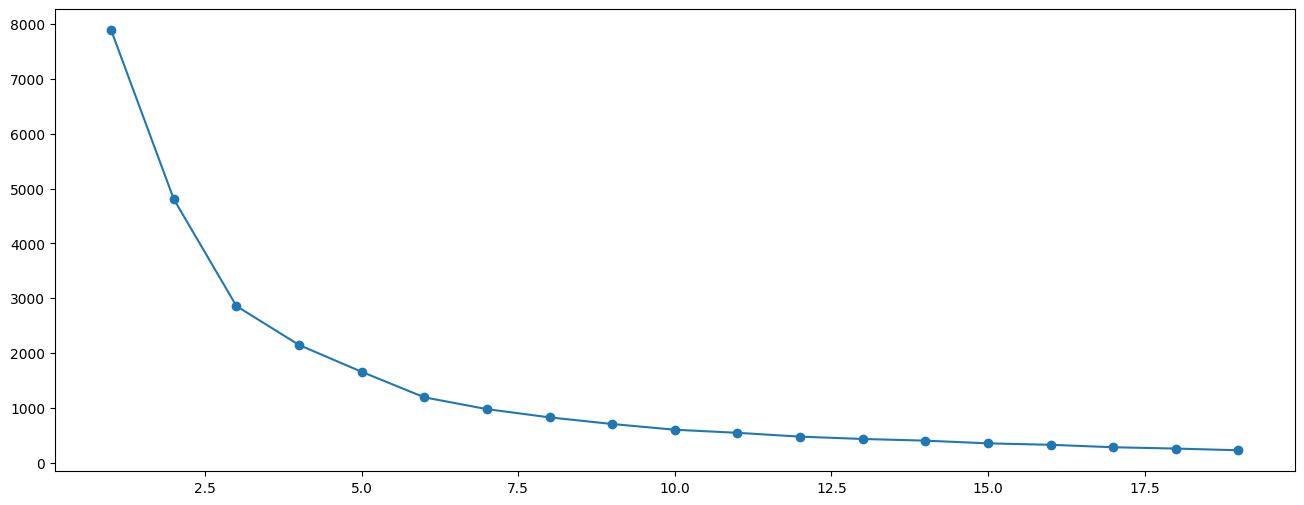

In [69]:
cluster_range = range( 1, 20 )
cluster_errors = []
for num_clusters in cluster_range:
    clusters = KMeans( num_clusters )
    clusters.fit( X_scaled )
    cluster_errors.append( clusters.inertia_ )

clusters_df = pd.DataFrame( { "num_clusters":cluster_range, 
                             "cluster_errors": cluster_errors } )
plt.figure(figsize=(16,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" );

In the plot above: X-axis represents the k and Y-axis represents cluster error. We are interested in finding Elbow
point, which defines the optimal value of k.
In this graph there are two optimal values for k; k=4 and k=6.

#### the number of clusters i am using is 4

In [70]:
# Fitting K-Means to the dataset
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 10)
y_kmeans = kmeans.fit_predict(X_scaled)
#beginning of the cluster numbering with 1 instead of 0
y_kmeans1=y_kmeans+1
# New list called cluster
cluster = list(y_kmeans1)
# Adding cluster to our data set
clustering_data['cluster'] = cluster

let see how the cluster looks

In [71]:
clustering_data.head(10)

,Confirmed,Deaths,cluster
0,2437.0,189.0,1
1,19136.0,190.0,1
2,7180.0,122.0,1
4,2188.0,59.0,1
5,75.0,2.0,1
6,292405.0,4599.0,1
7,7228.0,244.0,1
8,0.0,0.0,1
9,152.0,0.0,1
10,17.0,0.0,1


We need to understand the intuition behind the clusters. To do that let's inspect the clusters. With the following
code, we calculate the mean value of k clusters.

In [73]:
kmeans_mean_cluster = pd.DataFrame(round(clustering_data.groupby('cluster').mean(),1))
kmeans_mean_cluster

,Confirmed,Deaths
cluster,,
1,539.5,2.0
2,2744829.0,66349.5
3,-1656199.3,-44129.1
4,591270.1,15198.0


As you can see our cluster 3 has the highest number of deaths and confirmed cases. Cluster 2 is the lowest. To
get an idea about the members in cluster 3, let's view them using the following code.

Similarly, to get an idea about the members in cluster 3, let's view them using the following code.

In [74]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 2]

,Province_State,cluster
215,France,2
268,Maharashtra,2
649,Turkey,2
3959,England,2


##### Q4. Discuss what do you think about other clusters?

#### ANSWER

In [75]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 3]

,Province_State,cluster
214,Wallis and Futuna,3
267,Madhya Pradesh,3
474,La Libertad,3
487,Unknown,3
591,Solomon Islands,3
647,Trinidad and Tobago,3
3956,British Virgin Islands,3


In [76]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 4]

,Province_State,cluster
220,Bayern,4
228,Nordrhein-Westfalen,4
246,Hungary,4
249,Andhra Pradesh,4
256,Delhi,4
264,Kerala,4
278,Tamil Nadu,4
282,Uttar Pradesh,4
286,Iran,4
287,Iraq,4


In [77]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 1]

,Province_State,cluster
0,Afghanistan,1
1,Albania,1
2,Algeria,1
4,Angola,1
5,Antigua and Barbuda,1
...,...,...
4009,Unknown,1
4010,Nauru,1
4011,Niue,1
4012,Tuvalu,1


From the analysis above clsuter 2 which include england  and france have highest number of confirmed cases and deaths and so are the high risk regions 

Now, we need to visualise the clustered data in a map. First let's see how our dataframe looks like.


In [78]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude,cluster
0,Afghanistan,Afghanistan,2437.0,189.0,33.768006,66.238514,1
1,Albania,Albania,19136.0,190.0,41.000028,19.999962,1
2,Algeria,Algeria,7180.0,122.0,28.000027,2.999983,1
4,Angola,Angola,2188.0,59.0,-11.877577,17.569124,1
5,Antigua and Barbuda,Antigua and Barbuda,75.0,2.0,17.223472,-61.955461,1


Let's assign a color to each cluster using the following method.

In [79]:
def get_color(cluster_id):
    if cluster_id == 2:
        return 'darkred'  #represent very high risk regions
    if cluster_id == 1:
        return 'green' #represent  low risk regions
    if cluster_id == 3:
        return 'blue'#represent high risk regions
    if cluster_id == 4:
        return 'yellow'  #represent mediumnrisk regions
 
data["color"] = data["cluster"].apply(lambda x: get_color(x))


Darkred signifies 2 which high risk regions with the highest number of   confirmed cases and Deaths
 
 Blue signifies 3 which  also are high risk regions with second the highest confirmed cases and Deaths

Yellow  signifies 4 which medium  risk regions with the third number of  confirmed cases and Deaths

Green signifies 1 which low  risk regions with the lowest number of   confirmed cases and Deaths accordin the analysis above 

Let's see how our dataframe looks now.

In [80]:
data.head(10)

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude,cluster,color
0,Afghanistan,Afghanistan,2437.0,189.0,33.768006,66.238514,1,green
1,Albania,Albania,19136.0,190.0,41.000028,19.999962,1,green
2,Algeria,Algeria,7180.0,122.0,28.000027,2.999983,1,green
4,Angola,Angola,2188.0,59.0,-11.877577,17.569124,1,green
5,Antigua and Barbuda,Antigua and Barbuda,75.0,2.0,17.223472,-61.955461,1,green
6,Argentina,Argentina,292405.0,4599.0,-34.996496,-64.967282,1,green
7,Armenia,Armenia,7228.0,244.0,40.769627,44.673665,1,green
8,Australian Capital Territory,Australia,0.0,0.0,-35.488350,149.002694,1,green
9,New South Wales,Australia,152.0,0.0,-31.875984,147.286949,1,green
10,Northern Territory,Australia,17.0,0.0,-19.851610,133.230337,1,green


As you can see, every state now has a color. Now let's put them in a map using the following code. The map
will be saved in the same folder as this notebook. It is named as "covid_map.html" and you can open it using a
web browser such as chrome. Please submit your .html file together with the notebook.

In [81]:
#create a map
this_map = folium.Map(location =[data["Latitude"].mean(), 
                                 data["Longitude"].mean()], zoom_start=5)

def plot_dot(point): 
    '''input: series that contains a numeric named latitude and a numeric named longitude
    this function creates a CircleMarker and adds it to your this_map'''
    folium.CircleMarker(location=[point.Latitude, point.Longitude],
                        radius=2, 
                        color=point.color,
                        weight=1).add_to(this_map)
 
 
#clustered_full.apply(,axis=1) #use this to iterate through every row in your dataframe
data.apply(plot_dot, axis = 1)


#Set the zoom to the maximum possible
this_map.fit_bounds(this_map.get_bounds())


#Save the map to an HTML file
this_map.save(os.path.join('covid2_map.html'))